# Inspect a single (N_knots, seed) run from the knot sweep

Loads the saved trajectory for any completed run and produces:
1. **Controls plot** in the style of `robust_iswap_detuned_2MHz_100ns.ipynb` (4 channels, knots overlaid, ±a_bound dashed lines)
2. **6-panel fidelity comparison** (linear top, log bottom, columns = ZI / IZ / ZZ) — robust pulse vs the default Gaussian-square reference

Setup constants must match the sweep configuration in `knot_sweep_2MHz_100ns.jl` (T_total_ns = 100, g_eff, etc.).

Output figures are saved alongside the run's trajectory (`controls.png`, `fidelity_vs_eps.png`).

In [1]:
using Pkg
Pkg.activate(@__DIR__)

using Piccolo
using LinearAlgebra
using Printf
using CairoMakie
using JLD2

const SWEEP_DIR = joinpath(@__DIR__, "knot_sweep_2MHz_100ns")
println("Sweep dir: ", SWEEP_DIR)

  Activating 

Sweep dir: /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/knot_sweep_2MHz_100ns

project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`


In [2]:
# ============================================================================ #
# Physics setup — must match knot_sweep_2MHz_100ns.jl exactly
# ============================================================================ #
XX = operator_from_string("XX"); YY = operator_from_string("YY")
XY = operator_from_string("XY"); YX = operator_from_string("YX")
XI = operator_from_string("XI"); YI = operator_from_string("YI")
IX = operator_from_string("IX"); IY = operator_from_string("IY")
IZ = operator_from_string("IZ"); ZI = operator_from_string("ZI")
ZZ = operator_from_string("ZZ")

const g_eff = 2π * 0.002
const δ₁₂   = 2π * 0.06
const Δ_mw1 = -2π * 0.00
const Δ_mw2 = +2π * 0.00

const a_bound      = 2π * 0.01
const drive_bounds = fill(a_bound, 4)
const σ_rise       = 1.0

const T_total_ns      = 100.0
const buffer_duration = 4 * σ_rise
const dt_edge         = 0.01

# Edge profiles (rise and fall — used to compute V_rise/V_fall and θ_goal)
const t_rise_fine = collect(0:dt_edge:buffer_duration)
const g_rise_fine = g_eff .* exp.(-(t_rise_fine .- buffer_duration).^2 ./ (2 * σ_rise^2))
const t_fall_fine = collect(0:dt_edge:buffer_duration)
const g_fall_fine = g_eff .* exp.(-(t_fall_fine).^2 ./ (2 * σ_rise^2))

const A_rise = sum(g_rise_fine) * dt_edge
const A_fall = sum(g_fall_fine) * dt_edge
const θ_goal = π/4 - A_rise - A_fall
@assert θ_goal > 0

const U_iswap = exp(-im * π/4 * (XX + YY))
const U_goal  = exp(-im * θ_goal * (XX + YY))
const V_rise  = exp(-im * A_rise * (XX + YY))
const V_fall  = exp(-im * A_fall * (XX + YY))

# Gate-frame Hamiltonian (identical to sweep)
function H_gate_frame(u, t)
    uX1, uY1, uX2, uY2 = u
    H = g_eff * (XX + YY)
    c1 = cos(Δ_mw1 * t); s1 = sin(Δ_mw1 * t)
    H += uX1 * (XI * c1 + YI * s1)
    H += uY1 * (YI * c1 - XI * s1)
    c2 = cos(Δ_mw2 * t); s2 = sin(Δ_mw2 * t)
    H += uX2 * (IX * c2 + IY * s2)
    H += uY2 * (IY * c2 - IX * s2)
    return H
end

println("θ_goal = ", round(θ_goal, digits=4), " rad")

θ_goal = 0.7538 rad


In [3]:
# ============================================================================ #
# Default Gaussian-square pulse (coupling only) — same construction as reference
# ============================================================================ #
function gaussian_square_area(flat_ns; g=g_eff, σ=σ_rise, dt=0.01, trunc=4)
    buf = trunc * σ
    t = collect(0:dt:buf)
    A_edge = sum(g .* exp.(-(t .- buf).^2 ./ (2σ^2))) * dt
    return 2 * A_edge + g * flat_ns
end

let target = π/4, lo = 0.0, hi = 400.0
    for _ in 1:100
        mid = (lo + hi) / 2
        gaussian_square_area(mid) < target ? (lo = mid) : (hi = mid)
    end
    global flat_default = (lo + hi) / 2
end

const buf_default = 4 * σ_rise
const dt_default  = 0.01
const T_default   = buf_default + flat_default + buf_default

const t_default = collect(0:dt_default:T_default)
const g_default = let g_arr = zeros(length(t_default))
    for (i, t) in enumerate(t_default)
        if t < buf_default
            g_arr[i] = g_eff * exp(-(t - buf_default)^2 / (2σ_rise^2))
        elseif t < buf_default + flat_default
            g_arr[i] = g_eff
        else
            g_arr[i] = g_eff * exp(-(t - buf_default - flat_default)^2 / (2σ_rise^2))
        end
    end
    g_arr
end

println("Default gaussian-square flat-top = ", round(flat_default, digits=3), " ns,  total = ", round(T_default, digits=2), " ns")

Default gaussian-square flat-top = 59.984 ns,  total = 67.98 ns


In [4]:
# ============================================================================ #
# Fidelity helpers — copied from robust_iswap_detuned_2MHz_100ns.ipynb
# ============================================================================ #
function simulate_edge_unitary(g_pulse, t_pulse, dt, ε_op, ε_val)
    N = length(g_pulse)
    T_ns = t_pulse[end]
    function H_edge_err(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end
    edge_sys = QuantumSystem(H_edge_err, Float64[]; time_dependent=true)
    ts_prop  = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy    = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)
    qtraj    = UnitaryTrajectory(edge_sys, dummy, Matrix{ComplexF64}(I, 4, 4))
    return qtraj(T_ns)
end

function simulate_full_gate_fidelity(traj, ε_op, ε_val)
    V_rise_err = simulate_edge_unitary(g_rise_fine, t_rise_fine, dt_edge, ε_op, ε_val)
    V_fall_err = simulate_edge_unitary(g_fall_fine, t_fall_fine, dt_edge, ε_op, ε_val)
    ts  = vec(traj[:t])
    us  = traj[:u]
    dus = traj[:du]
    H_with_error(u, t) = H_gate_frame(u, t) + ε_val * ε_op
    err_sys    = QuantumSystem(H_with_error, drive_bounds; time_dependent=true)
    nlp_pulse  = CubicSplinePulse(us, dus, ts)
    qtraj      = UnitaryTrajectory(err_sys, nlp_pulse, U_goal)
    U_flat_err = qtraj(ts[end])
    U_full_err = V_fall_err * U_flat_err * V_rise_err
    return abs2(tr(U_iswap' * U_full_err)) / 4^2
end

function simulate_default_fidelity(g_pulse, t_pulse, dt, ε_op, ε_val)
    N = length(g_pulse)
    T_ns = t_pulse[end]
    function H_default(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end
    def_sys = QuantumSystem(H_default, Float64[]; time_dependent=true)
    ts_prop = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy   = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)
    qtraj   = UnitaryTrajectory(def_sys, dummy, U_iswap)
    return abs2(tr(U_iswap' * qtraj(T_ns))) / 4^2
end

simulate_default_fidelity (generic function with 1 method)

In [5]:
# ============================================================================ #
# Main analysis function
# ============================================================================ #
const ERRORS = [(ZI, "ZI", :red), (IZ, "IZ", :blue), (ZZ, "ZZ", :green)]
const F_THRESHOLD = 0.9999

function analyze_run(N_knots::Int, seed::Int;
                     εs        = collect(range(-0.02, 0.02, length=101)),
                     save_figs = true)
    run_dir = joinpath(SWEEP_DIR, "N_knots_$(lpad(N_knots, 2, '0'))", "seed_$(seed)")
    isdir(run_dir) || error("No run directory: $run_dir")
    traj_path = joinpath(run_dir, "trajectory.jld2")
    isfile(traj_path) || error("trajectory.jld2 not found in $run_dir")

    @info "Loading trajectory" run_dir
    traj = JLD2.load(traj_path, "traj")

    ts  = vec(traj[:t])
    us  = traj[:u]
    dus = traj[:du]

    U_flat = iso_vec_to_operator(traj[:Ũ⃗][:, end])
    F_flat = abs2(tr(U_goal' * U_flat)) / 4^2
    U_full = V_fall * U_flat * V_rise
    F_full = abs2(tr(U_iswap' * U_full)) / 4^2
    @printf("F(flat-top → U_goal)  = %.8f\n", F_flat)
    @printf("F(full gate → iSWAP)  = %.8f\n", F_full)

    # ---- Controls plot ----
    pulse_fine = CubicSplinePulse(us, dus, ts)
    ts_fine    = collect(LinRange(ts[1], ts[end], 2000))
    us_fine    = sample(pulse_fine, ts_fine)

    fig_ctrl = Figure(size = (900, 400), fontsize = 22)
    ax = Axis(fig_ctrl[1, 1];
        xlabel = "t (ns)", ylabel = "amplitude (rad/ns)",
        title  = "Optimized Flat-Top Controls — N_knots=$(N_knots), seed=$(seed)")
    labels      = ["u_X1", "u_Y1", "u_X2", "u_Y2"]
    colors_ctrl = [:crimson, :orange, :forestgreen, :purple]
    for (i, (lbl, col)) in enumerate(zip(labels, colors_ctrl))
        lines!(ax, ts_fine, vec(us_fine[i, :]); label = lbl, color = col, linewidth = 2)
        scatter!(ax, ts, vec(us[i, :]); color = :black, markersize = 5)
    end
    hlines!(ax, [a_bound, -a_bound]; linestyle = :dash, color = :gray, label = "±bound")
    axislegend(ax; position = :rt)
    save_figs && save(joinpath(run_dir, "controls.png"), fig_ctrl)
    display(fig_ctrl)

    # ---- Fidelity vs ε sweep ----
    @info "Sweeping ε for $(length(ERRORS)) errors × $(length(εs)) values..."
    F_robust  = Dict{String, Vector{Float64}}()
    F_default = Dict{String, Vector{Float64}}()
    for (op, name, _) in ERRORS
        F_robust[name]  = [simulate_full_gate_fidelity(traj, op, ε)            for ε in εs]
        F_default[name] = [simulate_default_fidelity(g_default, t_default, dt_default, op, ε) for ε in εs]
        println("  $name done")
    end

    # ---- 6-panel comparison plot ----
    fig_fid = Figure(fontsize = 22, size = (1200, 800))
    for (col, (op, name, ecol)) in enumerate(ERRORS)
        # top: linear fidelity
        ax_lin = Axis(fig_fid[1, col];
            xlabel = "ε (rad/ns)", ylabel = "Fidelity", title = "$name error")
        lines!(ax_lin, εs ./ (2*pi) .* 1000, F_default[name]; color = ecol, linewidth = 2,
               linestyle = :dash, label = "Default (GS)")
        lines!(ax_lin, εs ./ (2*pi) .* 1000, F_robust[name];  color = ecol, linewidth = 2,
               label = "Robust")
        hlines!(ax_lin, [F_THRESHOLD]; linestyle = :dot, color = :black, linewidth = 0.5)
        col == 1 && axislegend(ax_lin; position = :lb)

        # bottom: log infidelity
        ax_log = Axis(fig_fid[2, col];
            xlabel = "ε (rad/ns)", ylabel = "1 − Fidelity", yscale = log10)
        lines!(ax_log, εs, max.(1 .- F_default[name], 1e-16); color = ecol,
               linewidth = 2, linestyle = :dash, label = "Default (GS)")
        lines!(ax_log, εs, max.(1 .- F_robust[name],  1e-16); color = ecol,
               linewidth = 2, label = "Robust")
        ylims!(ax_log, 1e-4, 1.0)
        col == 1 && axislegend(ax_log; position = :lb)
    end
    for col in 1:length(ERRORS)
        linkxaxes!(contents(fig_fid[1, col])[1], contents(fig_fid[2, col])[1])
    end
    save_figs && save(joinpath(run_dir, "fidelity_vs_eps.png"), fig_fid)
    display(fig_fid)

    return (
        traj      = traj,
        F_flat    = F_flat,
        F_full    = F_full,
        εs        = εs,
        F_robust  = F_robust,
        F_default = F_default,
        controls_fig = fig_ctrl,
        fidelity_fig = fig_fid,
    )
end

analyze_run (generic function with 1 method)

## Run on a specific (N_knots, seed)

Edit the cell below. Saves `controls.png` and `fidelity_vs_eps.png` into that run's directory.

┌ Info: Loading trajectory
│   run_dir = /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/knot_sweep_2MHz_100ns/N_knots_20/seed_42
└ @ Main /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:15


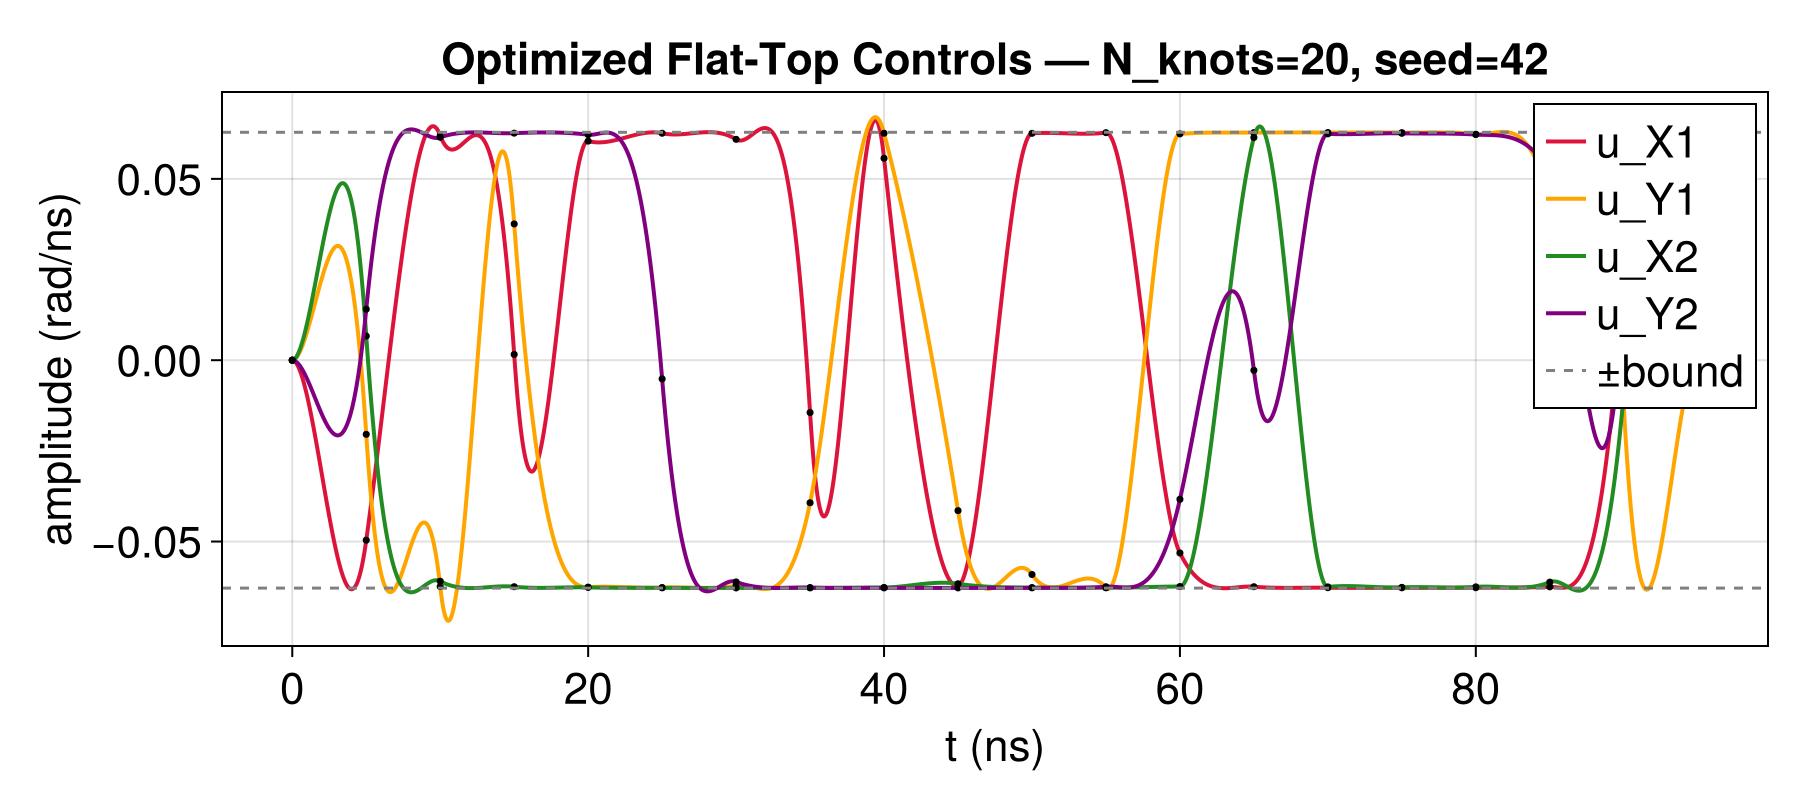

F(flat-top → U_goal)  = 0.99990007
F(full gate → iSWAP)  = 0.99990007


┌ Info: Sweeping ε for 3 errors × 101 values...
└ @ Main /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:50


  ZI done
  IZ done
  ZZ done


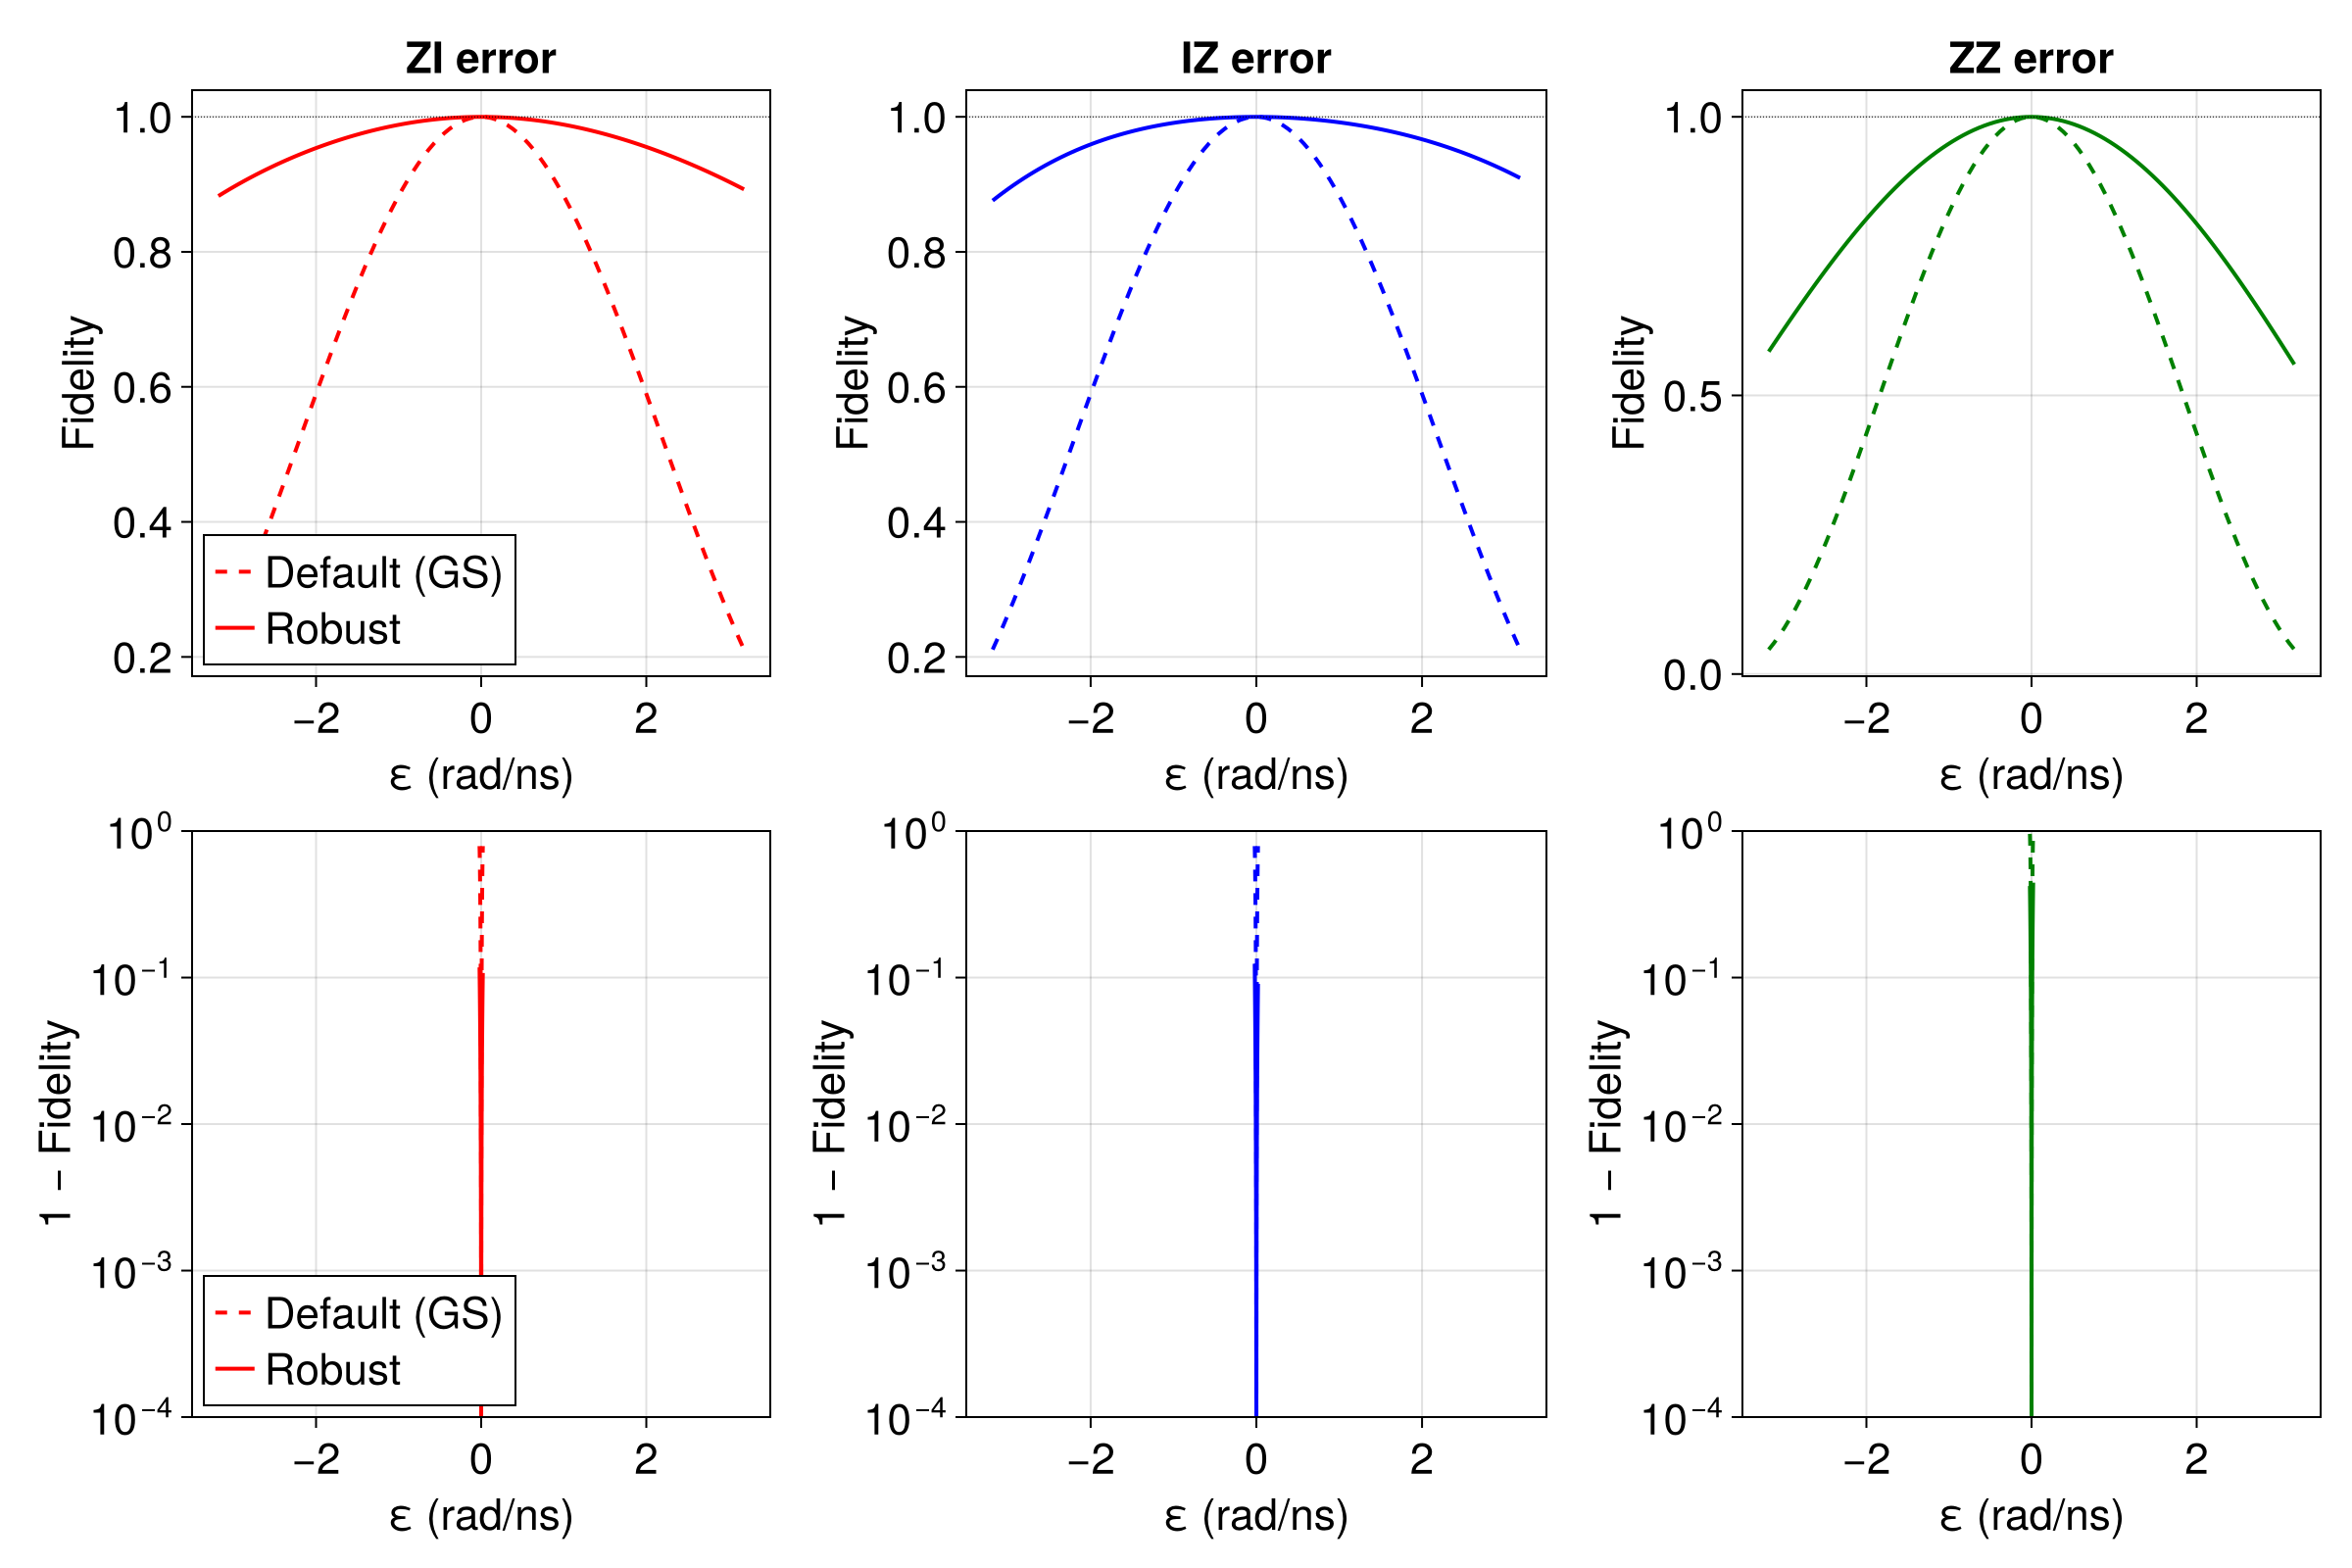

(traj = N = 20, (Ũ⃗ = 1:32, → Δt = 33:33, t = 34:34, u = 35:38, du = 39:42, var_Ũ⃗ = 43:170), F_flat = 0.9999000694558369, F_full = 0.9999000694558369, εs = [-0.02, -0.0196, -0.0192, -0.0188, -0.0184, -0.018, -0.0176, -0.0172, -0.0168, -0.0164  …  0.0164, 0.0168, 0.0172, 0.0176, 0.018, 0.0184, 0.0188, 0.0192, 0.0196, 0.02], F_robust = Dict("ZI" => [0.8826694469593048, 0.8874416792760359, 0.8920945570270024, 0.8966305298135697, 0.901051953013198, 0.9053610768664787, 0.9095600534062845, 0.9136509231639443, 0.9176356147003234, 0.9215159486904069  …  0.9259940344596633, 0.9225593372116282, 0.9190553266364181, 0.915481928547887, 0.9118389608199937, 0.9081261382213848, 0.904343060401012, 0.9004892128222678, 0.896563975116027, 0.8925665935984247], "IZ" => [0.8758938004434029, 0.8819668921141501, 0.8878411019122472, 0.8935191883405661, 0.8990040484744883, 0.9042987039649377, 0.909406296992893, 0.9143300684290407, 0.9190733530539278, 0.923639560309607  …  0.9413259232794567, 0.9381841090420587,

In [6]:
result = analyze_run(20, 42)

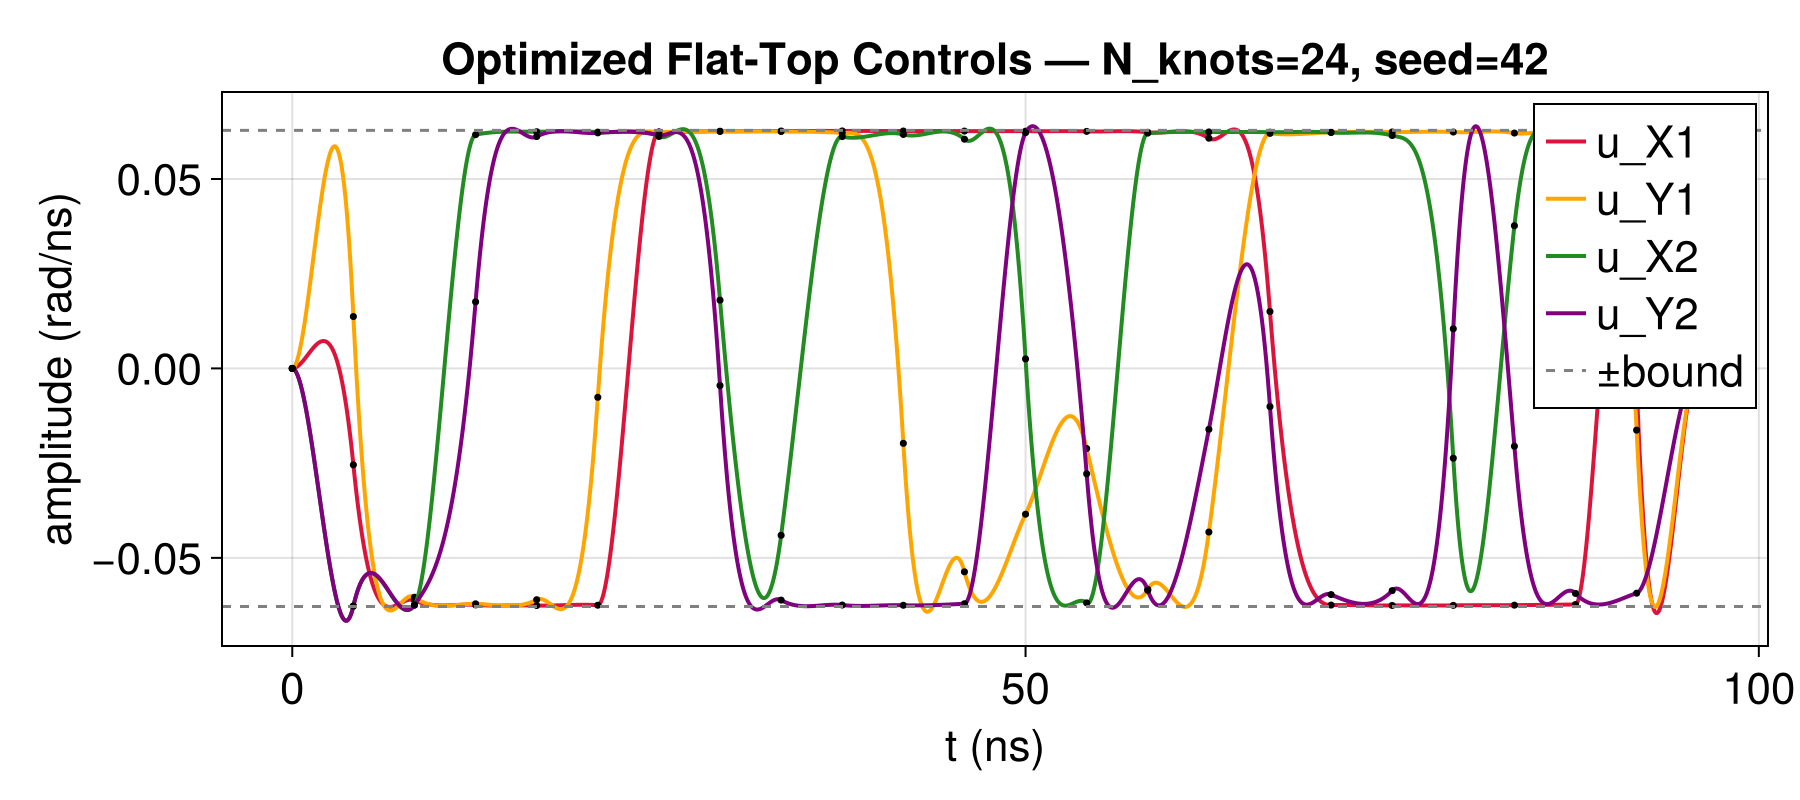

F(flat-top → U_goal)  = 0.99990942
F(full gate → iSWAP)  = 0.99990942


┌ Info: Loading trajectory
│   run_dir = /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/knot_sweep_2MHz_100ns/N_knots_24/seed_42
└ @ Main /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:15
┌ Info: Sweeping ε for 3 errors × 101 values...
└ @ Main /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:50


  ZI done
  IZ done
  ZZ done


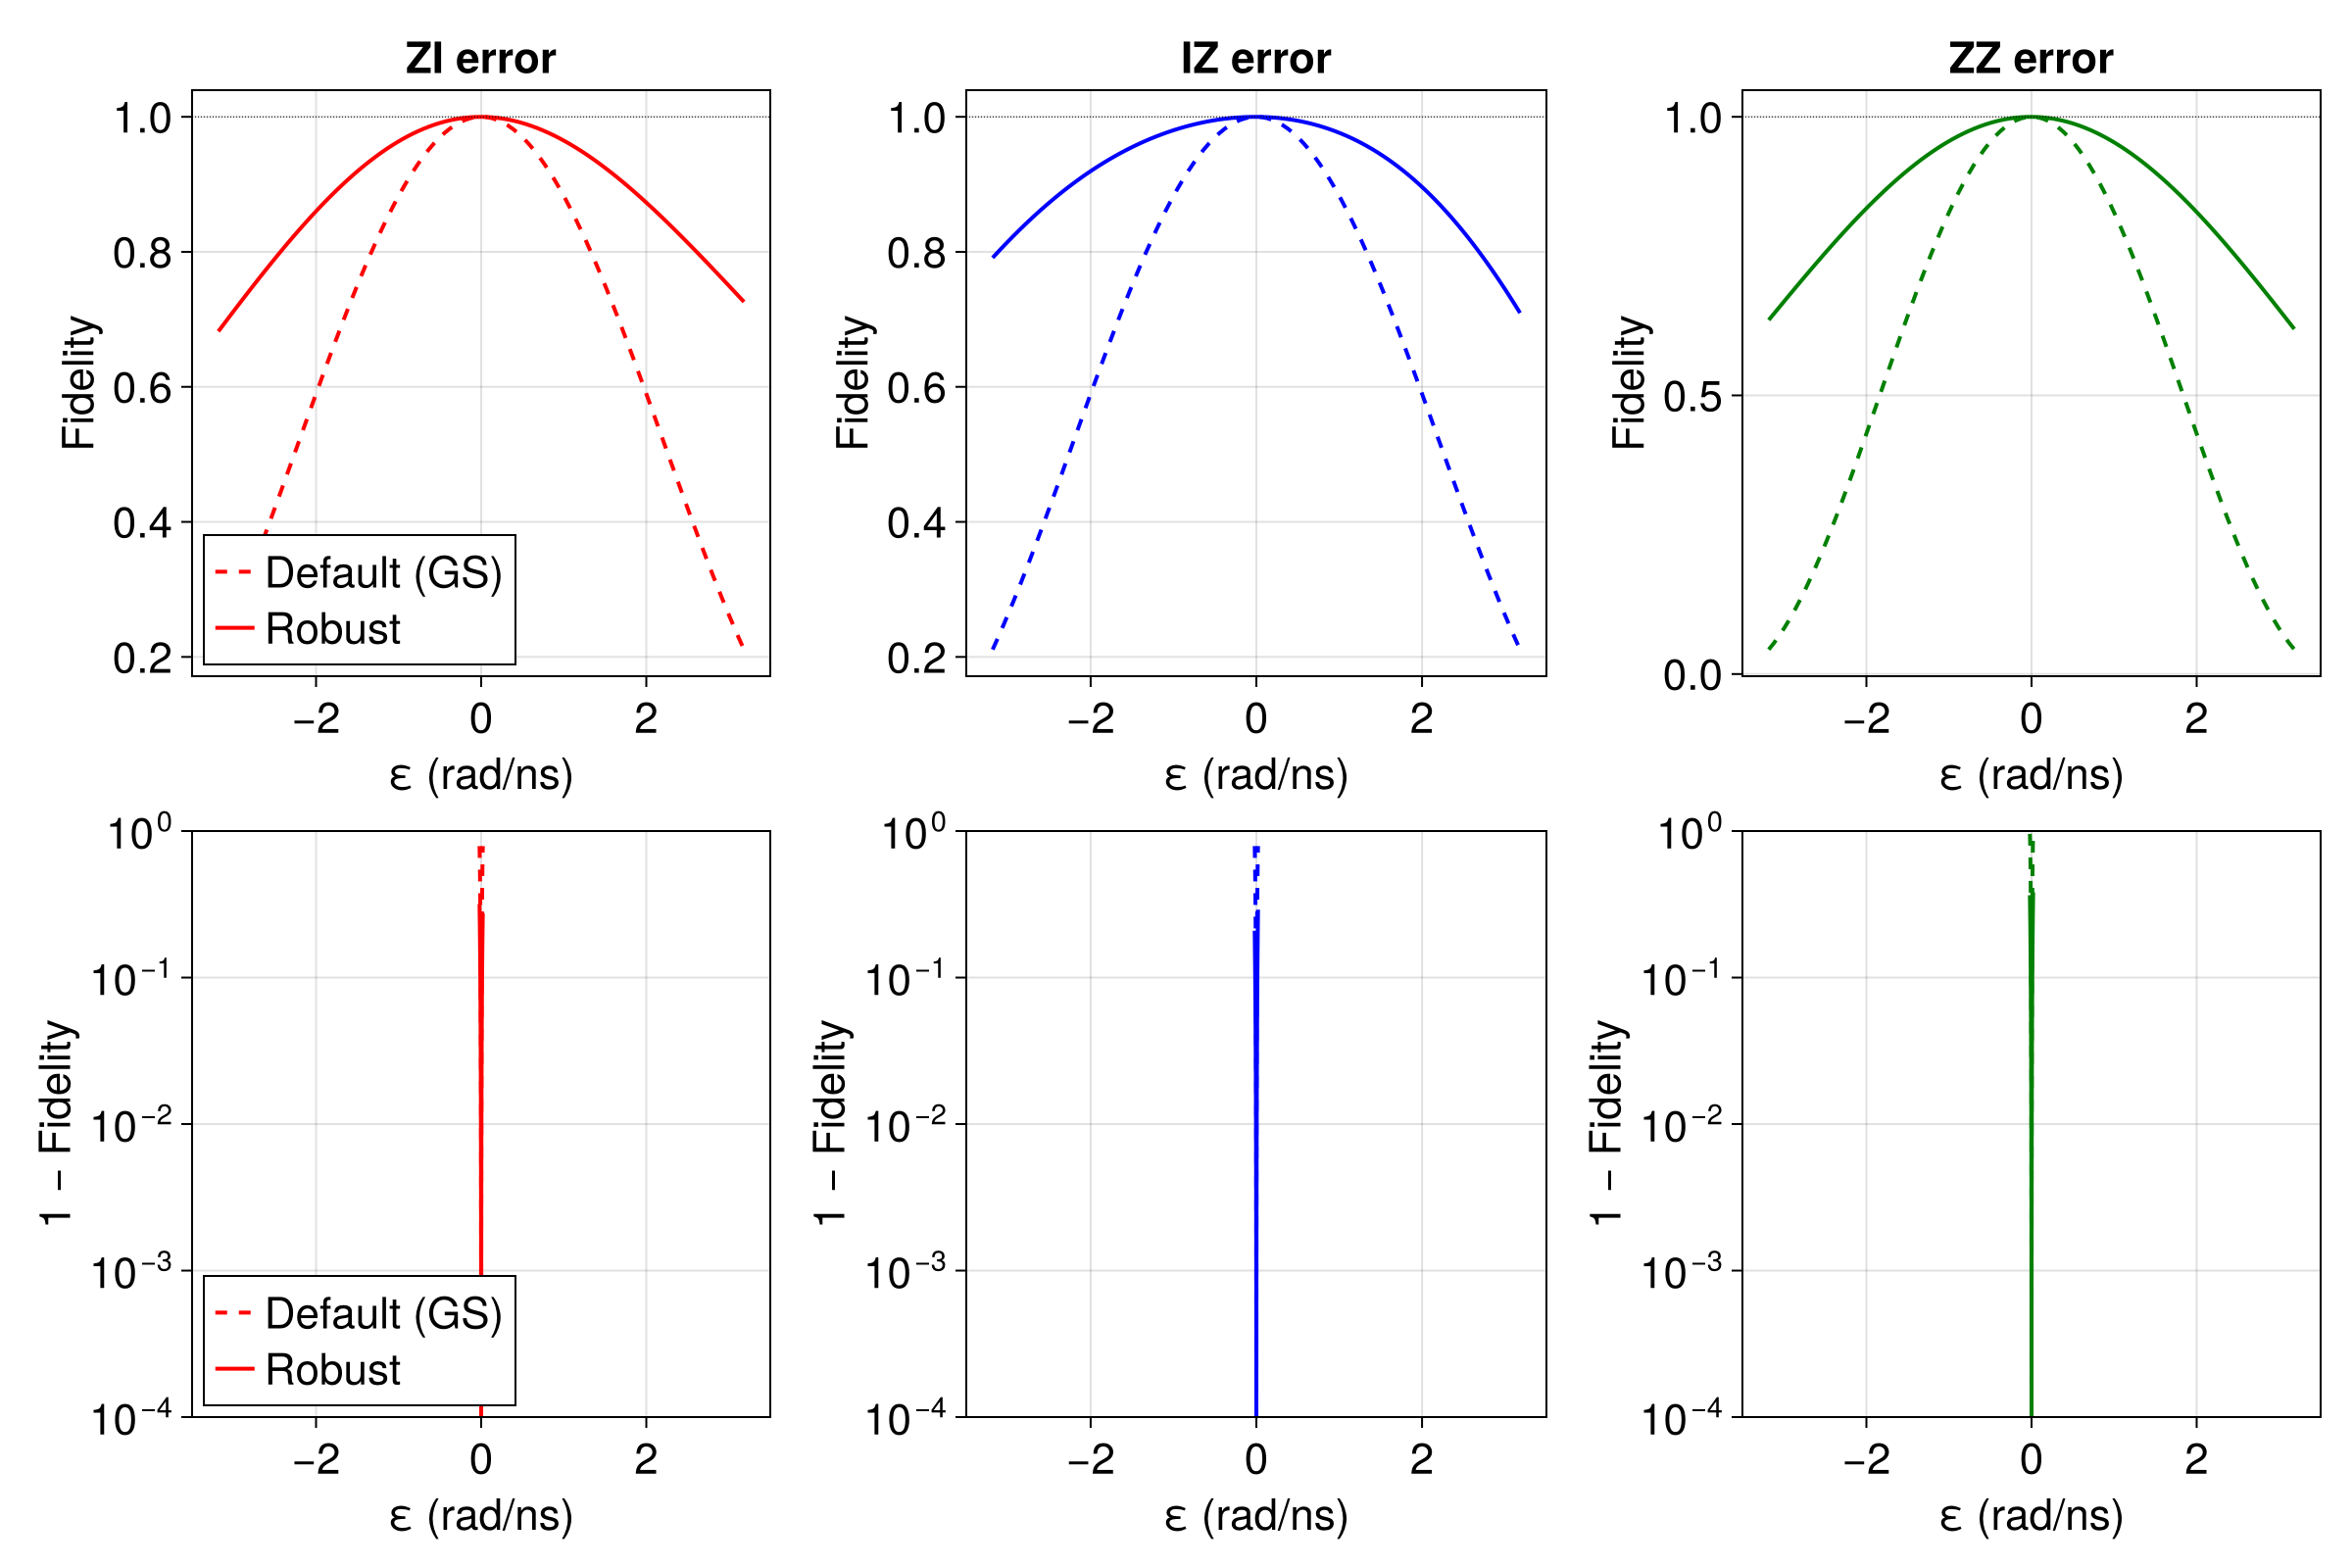

(traj = N = 24, (Ũ⃗ = 1:32, → Δt = 33:33, t = 34:34, u = 35:38, du = 39:42, var_Ũ⃗ = 43:170), F_flat = 0.9999094189350975, F_full = 0.9999094189350975, εs = [-0.02, -0.0196, -0.0192, -0.0188, -0.0184, -0.018, -0.0176, -0.0172, -0.0168, -0.0164  …  0.0164, 0.0168, 0.0172, 0.0176, 0.018, 0.0184, 0.0188, 0.0192, 0.0196, 0.02], F_robust = Dict("ZI" => [0.682186252760169, 0.6925273551804317, 0.7028269948774833, 0.7130771296731602, 0.7232696433179082, 0.73339634639232, 0.7434489944183139, 0.7534192980041521, 0.7632989341300489, 0.7730795611259323  …  0.7998403066880044, 0.7917886884764037, 0.7836825038592607, 0.7755279515187529, 0.7673310944669536, 0.7590978507479674, 0.7508339924089013, 0.7425451368952932, 0.7342367446951087, 0.7259141132983672], "IZ" => [0.7912035266137399, 0.7996481232259134, 0.8079289609177018, 0.8160428969550817, 0.8239870908752969, 0.8317590015572994, 0.8393563760786396, 0.846777253168077, 0.8540199570709265, 0.8610830742251798  …  0.8126045171210816, 0.802298884132975

In [7]:
result = analyze_run(24, 42)